In [1]:
# system
from pathlib import Path
from tqdm import tqdm
import pickle

# analysis
import numpy as np
import pandas as pd
import pynapple as nap
from scipy import stats
import glob 
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import warnings
import os

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import patsy
from scipy.stats import pearsonr
from matplotlib.collections import LineCollection

from umap import UMAP
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
import pickle
import os
from collections import defaultdict

# Here we repeat the imports and instantiate ONE, so this cell can also be run stand-alone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.ndimage

from iblutil.numerical import bincount2D
from iblatlas.atlas import BrainRegions
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from ibl_style.style import figure_style

# set the IBL style for figures
# from ibl_style.style import figure_style
# figure_style()
from reproducible_ephys_functions import get_insertions
from functions import idxs_from_files
from one.api import ONE
one= ONE()

In [2]:
prefix = '/home/ines/repositories/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/'


# Load data

In [3]:
insertions = get_insertions(level=0, one=one, freeze='freeze_2024_03')
repro_ephys_insertions = pd.DataFrame.from_dict(insertions)

In [4]:
repro_eid = repro_ephys_insertions['probe_insertion']

In [5]:
import brainwidemap
# this dataframe holds a summary of all the sessions
# and for us importantly, the eids and pids
bwm_df = brainwidemap.bwm_query()  # each row of this dataframe is a recording

n_sessions = bwm_df["eid"].unique().shape[0]
n_insertions = bwm_df["pid"].unique().shape[0]
print(
    f"{n_sessions} sessions with {n_insertions} individual neuropixel recordings"
)
# bwm_df.head()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
459 sessions with 699 individual neuropixel recordings


In [6]:
bwm_pid = bwm_df['pid'].unique()

## Getting units from the brainwide map

In [7]:
units_df = brainwidemap.bwm_units(one)
n_units = units_df.shape[0]
print(f"{n_units} units present in the table")
# units_df.head()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01
62990 units present in the table


In [8]:
# use_eid = lda_pid
use_eid = repro_eid
# use_eid = bwm_pid

In [9]:
len(use_eid)

89

In [10]:
repro_units = units_df.loc[units_df['pid'].isin(list(use_eid))]

## Querying and loading the data

Then we will query the brain region ACA. ACA has many sub-regions, and we need to get the list of neurons belinging to any of the sub-regions.

In [11]:
BRAIN_REGIONS = ['PPC', 'CA1', 'DG', 'LP', 'PO']  # Reproducible ephys regions
BRAIN_REGIONS = ['VISa', 'VISam', 'CA1', 'DG', 'LP', 'PO']  # Reproducible ephys regions

regions = BrainRegions()
aca_leaf_nodes = regions.descendants(regions.acronym2id(BRAIN_REGIONS))
# print(f"List of regions to query: \n {aca_leaf_nodes['acronym']}")
BRAIN_REGIONS = repro_units['Beryl'].unique()  # All available in the session query

# Process and save PETH with trial info

In [12]:
# LOAD DATA
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'

all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]
idxs, mouse_names = idxs_from_files(design_matrices)

save_states_path = prefix + 'representation_learning_variability/paper-individuality/data/states_files/'

# Individual sessions

In [13]:
# Identify sessions available to process
sessions_to_process = []
for m, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]
    
    sessions_to_process.append((mouse_name, session))
print(f"Found {len(sessions_to_process)} sessions to process.")

Found 218 sessions to process.


In [14]:
save_states_path = prefix + 'representation_learning_variability/paper-individuality/data/neuron_files/'
filepaths = [os.path.join(save_states_path, filename) for filename in os.listdir(save_states_path)]

## LDA axis

In [151]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# session_cluster = pd.read_parquet(data_path+'cluster_per_session')
lda = pd.read_pickle(data_path+'mouse_LDA_5_bins_cut')
# lda = pd.read_pickle(data_path+'mouse_LDA_3_bins_cut')
# lda = pd.read_pickle(data_path+'mouse_LDA_quadrants')
# lda = pd.read_pickle(data_path+'reaction_PLS_5_bins')
lda_eid = lda.loc[lda['session'].isin(list(bwm_df.eid)), 'session']
lda_pid = bwm_df.loc[bwm_df['eid'].isin(lda_eid), 'pid']

In [17]:
def get_psth(df, area, event_bins, pre_bins=20, post_bins=50):
    all_trials = []
    for event in event_bins:
        # Define window
        start = event - pre_bins
        end = event + post_bins
        
        # Ensure we don't go out of bounds
        if start >= 0 and end < len(df):
            # Extract data for all columns ending in '_spike_std'
            window = df.loc[start:end-1, [f'{area}_spike_mean']]
            all_trials.append(window.values)
            
    # Convert to 3D array: (Trials, Time, Areas)
    return np.array(all_trials)


def get_psth(df, col_name, events, pre=.5, post=1):
    all_trials = []
    for event in events:
        # Define window
        start = event - pre
        end = event + post
        # Extract data for all columns ending in '_spike_std'
        window = df.loc[(df['Bin'] >= start) & (df['Bin'] < end), col_name]
        if len(window) == int((pre + post) * 60):  # Assuming 60 Hz sampling rate
            all_trials.append(window.values)
            
    return np.array(all_trials)

In [2]:
filepaths = [os.path.join(save_states_path, filename) for filename in os.listdir(save_states_path)][:1]
count_intersect = []
summary_df = pd.DataFrame()
for filepath in filepaths:
    # try:
        with open(filepath, 'rb') as f:
            state_with_spikes = pickle.load(f).dropna(subset=['Bin', 'most_likely_states'])
            
        new_df = state_with_spikes.reset_index(drop=True)
        session_name = state_with_spikes['session'].iloc[0]

        # 1. Define the binning factor (e.g., 5 means 5 bins become 1 new bin)
        bin_factor = 5 
        new_df['Coarse_Bin'] = new_df['Bin'] // bin_factor

        # 3. Aggregate all numeric columns by the new bin
        # We sum the spike counts, but mean the 'most_likely_states' or other labels
        numeric_cols = [c for c in new_df.columns if '_spike_count' in c]
        other_cols = ['most_likely_states', 'broader_label'] # Add any non-spike columns you need

        agg_dict = {col: 'sum' for col in numeric_cols}
        agg_dict.update({col: 'first' for col in other_cols}) # Keeps the label of the first bin

        # 4. Perform the re-binning
        new_df = new_df.groupby(['Coarse_Bin', 'goCueTrigger_times']).agg(agg_dict).reset_index()

        # Now proceed with your existing area processing code...
        spike_columns = [col for col in new_df.columns if '_spike_count' in col]
        areas = np.unique([col.split('_neuron_')[0] for col in spike_columns])

        for area in areas:
            area_columns = [col for col in new_df.columns if area in col and '_spike_count' in col]
            new_df[f'{area}_spike_std'] = new_df[area_columns].std(axis=1)
            new_df[f'{area}_spike_mean'] = new_df[area_columns].mean(axis=1)


NameError: name 'save_states_path' is not defined

### Mean and std across neurons

In [ ]:
filepaths = [os.path.join(save_states_path, filename) for filename in os.listdir(save_states_path)][:1]
count_intersect = []
summary_df = pd.DataFrame()
for filepath in filepaths:
    # try:
        with open(filepath, 'rb') as f:
            state_with_spikes = pickle.load(f).dropna(subset=['Bin', 'most_likely_states'])
            
        new_df = state_with_spikes.reset_index(drop=True)
        session_name = state_with_spikes['session'].iloc[0]

        spike_columns = [col for col in state_with_spikes.columns if '_spike_count' in col]
        areas = [col.split('_neuron_')[0] for col in spike_columns]
        new_df[col]

        for area in areas:
            area_columns = [col for col in state_with_spikes.columns if area in col]

            new_df[f'{area}_spike_std'] = new_df[area_columns].std(axis=1)
            new_df[f'{area}_spike_mean'] = new_df[area_columns].mean(axis=1)

        # summary_df = pd.concat([summary_df, new_df], ignore_index=True)
        
    # except Exception as e:
    #     print(f"Error processing {filepath}: {e}")

### Mean and std across trials only

In [ ]:
filepaths = [os.path.join(save_states_path, filename) for filename in os.listdir(save_states_path)]
count_intersect = []
summary_df = pd.DataFrame()
for filepath in filepaths:
    try:
        session_df = pd.DataFrame()
        per_neuron = pd.DataFrame()
        with open(filepath, 'rb') as f:
            state_with_spikes = pickle.load(f).dropna(subset=['Bin', 'most_likely_states'])
            
        new_df = state_with_spikes.reset_index(drop=True)
        session_name = state_with_spikes['session'].iloc[0]
        area_names = np.unique([col.split('_neuron_')[0] for col in spike_columns])

        spike_columns = [col for col in state_with_spikes.columns if '_spike_count' in col]
        events = np.array(new_df['goCueTrigger_times'].unique())
        
        for col in spike_columns:
            psth_data = get_psth(new_df, col, events, pre=.5, post=1)
            neuron_std = psth_data.std(axis=0)**2    
            per_neuron[f'{col}_std'] = np.ravel(neuron_std)

        for area in area_names:
            area_columns = [col for col in per_neuron.columns if area in col]
            session_df[f'{area}_spike_std'] = per_neuron[area_columns].std(axis=1)
            session_df[f'{area}_spike_mean'] = per_neuron[area_columns].mean(axis=1)

        session_df['session'] = session_name
        summary_df = pd.concat([summary_df, session_df], ignore_index=True)
        
    except Exception as e:
        print(f"Error processing {filepath}: {e}")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/states_files/'

## Std after z-scoring

In [87]:
# Initialize a list to hold the session-level PSTH data
all_session_data = []
for filepath in filepaths:
    try:
        with open(filepath, 'rb') as f:
            state_with_spikes = pickle.load(f).dropna(subset=['Bin', 'most_likely_states'])
            
        new_df = state_with_spikes.reset_index(drop=True)
        session_name = state_with_spikes['session'].iloc[0]
        
        spike_columns = [col for col in new_df.columns if '_spike_count' in col]
        area_names = np.unique([col.split('_neuron_')[0] for col in spike_columns])
        events = np.array(new_df['goCueTrigger_times'].unique())

        # # 1. Z-score all neurons
        # for col in spike_columns:
        #     col_mean = new_df[col].mean()
        #     col_std = new_df[col].std()
        #     new_df[col] = (new_df[col] - col_mean) / (col_std + 1e-6) # 1e-6 to avoid div by zero
            
        # 1. Compute PSTH per area
        # We store them in a temporary structure
        for area in area_names:
            area_cols = [c for c in spike_columns if area in c]
            # Get PSTH for ALL neurons in this area at once (Trials, Time, Neurons)
            # Assuming get_psth returns: (n_trials, n_time_bins)
            area_psths = [get_psth(new_df, col, events, pre=.2, post=0) for col in area_cols]
            area_psths = np.stack(area_psths, axis=-1) # (Trials, Time, Neurons)
            # 2. Calculate Synchrony (Variance across neurons for each time bin)
            # Result is (Trials, Time)
            trial_variances = area_psths.mean(axis=-1) 
            # 3. Average across trials to get (Time) for this session
            mean_session_sync = trial_variances.mean(axis=0)
            
            # 4. Append to long-format list
            for t_idx, val in enumerate(mean_session_sync):
                all_session_data.append({
                    'session': session_name,
                    'area': area,
                    'time_bin': t_idx,
                    'pop_sync': val})
                
    except Exception as e:
        print(f"Error: {e}")

# Convert to DataFrame
summary_df = pd.DataFrame(all_session_data)

Error: invalid load key, '\x1b'.


## Fano factor

In [26]:
# Initialize a list to hold the session-level PSTH data
all_session_data = []
for filepath in filepaths:
    try:
        with open(filepath, 'rb') as f:
            state_with_spikes = pickle.load(f).dropna(subset=['Bin', 'most_likely_states'])
            
        new_df = state_with_spikes.reset_index(drop=True)
        session_name = state_with_spikes['session'].iloc[0]
        
        spike_columns = [col for col in new_df.columns if '_spike_count' in col]
        area_names = np.unique([col.split('_neuron_')[0] for col in spike_columns])
        events = np.array(new_df['goCueTrigger_times'].unique())

        # # 1. Z-score all neurons
        # for col in spike_columns:
        #     col_mean = new_df[col].mean()
        #     col_std = new_df[col].std()
        #     new_df[col] = (new_df[col] - col_mean) / (col_std + 1e-6) # 1e-6 to avoid div by zero

        for area in area_names:
            area_cols = [c for c in spike_columns if area in c]
            
            # 1. Get PSTH: (n_trials, n_time_bins, n_neurons_in_area)
            # Assuming get_psth returns: (n_trials, n_time_bins)
            area_psths = [get_psth(new_df, col, events, pre=.5, post=1) for col in area_cols]
            area_psths = np.stack(area_psths, axis=-1) 
            # 2. Compute Statistics ACROSS TRIALS (axis=0)
            # mean_across_trials: (n_time_bins, n_neurons)
            mean_across_trials = area_psths.mean(axis=0)
            # var_across_trials: (n_time_bins, n_neurons)
            var_across_trials = area_psths.var(axis=0)
            # 3. Calculate Fano Factor: Variance / Mean
            # Add small epsilon to avoid division by zero
            fano_factor_matrix = var_across_trials / (mean_across_trials + 1e-6)
            # 4. Average across neurons to get (n_time_bins) for this session
            mean_session_ff = fano_factor_matrix.mean(axis=1)
            
            # 5. Append to data list (using 'pop_sync' or a new 'fano_factor' key)
            for t_idx, val in enumerate(mean_session_ff):
                all_session_data.append({
                    'session': session_name,
                    'area': area,
                    'time_bin': t_idx,
                    'pop_sync': val 
                    })
                
    except Exception as e:
        print(f"Error: {e}")

# Convert to DataFrame
summary_df = pd.DataFrame(all_session_data)

Error: invalid load key, '\x1b'.


## FF change

In [93]:
# Initialize a list to hold the session-level PSTH data
all_session_data = []
for filepath in filepaths:
    try:
        with open(filepath, 'rb') as f:
            state_with_spikes = pickle.load(f).dropna(subset=['Bin', 'most_likely_states'])
            
        new_df = state_with_spikes.reset_index(drop=True)
        session_name = state_with_spikes['session'].iloc[0]
        
        spike_columns = [col for col in new_df.columns if '_spike_count' in col]
        area_names = np.unique([col.split('_neuron_')[0] for col in spike_columns])
        events = np.array(new_df['goCueTrigger_times'].unique())

        # # 1. Z-score all neurons
        # for col in spike_columns:
        #     col_mean = new_df[col].mean()
        #     col_std = new_df[col].std()
        #     new_df[col] = (new_df[col] - col_mean) / (col_std + 1e-6) # 1e-6 to avoid div by zero

        for area in area_names:
            area_cols = [c for c in spike_columns if area in c]
            
            # 1. Get PSTH: (n_trials, n_time_bins, n_neurons_in_area)
            area_psths = [get_psth(new_df, col, events, pre=.5, post=1) for col in area_cols]
            area_psths = np.stack(area_psths, axis=-1) 
            
            # 2. Compute Statistics ACROSS TRIALS (axis=0)
            mean_across_trials = area_psths.mean(axis=0) # (time, neurons)
            var_across_trials = area_psths.var(axis=0)   # (time, neurons)
            
            # 3. Calculate Fano Factor Matrix: (time, neurons)
            ff_matrix = var_across_trials / (mean_across_trials + 1e-6)
            
            # 4. Compute 'Before' (pre-stimulus) and 'After' (post-stimulus) FF per neuron
            # Assuming your get_psth pre=0.5 and post=1.0 covers the stimulus
            ff_before = ff_matrix[20:30, :].mean(axis=0) # Mean across time (pre)
            ff_after = ff_matrix[30:40, :].mean(axis=0)  # Mean across time (post)
            
            # 5. Calculate the change (Difference or Ratio)
            # Difference: After - Before (Negative means quenching of variability)
            ff_change = ff_after - ff_before 
            
            # 6. Average across all neurons in the area
            area_mean_change = ff_change.mean()
            
            # 7. Append to summary
            all_session_data.append({
                'session': session_name,
                'area': area,
                'ff_change': area_mean_change,
                'ff_before_mean': ff_before.mean(),
                'ff_after_mean': ff_after.mean()
            })

                
    except Exception as e:
        print(f"Error: {e}")

# Convert to DataFrame
summary_df = pd.DataFrame(all_session_data)

Error: invalid load key, '\x1b'.


In [44]:
merged_df = summary_df.merge(lda[['mouse_name', 'session', 0, 1, 'binned1']], on='session', how='left')

# merged_df = summary_df.merge(lda[['session', 0, 1, 'quadrant']], on='session', how='left')


In [29]:
# plt.figure(figsize=(10, 5))
sns.barplot(data=merged_df, y='pop_sync', x='binned2')
plt.show()

ValueError: Could not interpret input 'binned2'

In [30]:
# plt.figure(figsize=(10, 5))
merged_df = summary_df.merge(lda[['session', 0, 1, 'binned1', 'binned2']], on='session', how='left').dropna()

component = 0
var = 'ff_before_mean'
plot_df = merged_df.groupby([component])[var].mean().reset_index()
plot_df = merged_df.copy()
sns.regplot(x=np.array(plot_df[component]).astype(float), y=(plot_df[var]).astype(float), color='black', ci=95) 
res = stats.pearsonr(np.array(plot_df[component]).astype(float), (plot_df[var]).astype(float))
print(res)

KeyError: 'Column not found: ff_before_mean'

In [305]:
merged_df = summary_df.merge(lda[['session', 0, 1]], on='session', how='left')
plot_df = merged_df.loc[(merged_df['time_bin']<30) & (merged_df['time_bin']>20)].groupby(['session', 'area', 0])['pop_sync'].mean().reset_index()
# sns.scatterplot(data=plot_df, x=0, y='pop_sync')
component = 0
sns.regplot(x=np.array(plot_df[component]).astype(float), y=(plot_df['pop_sync']).astype(float), color='black', ci=95) 
res = stats.pearsonr(np.array(plot_df[component]).astype(float), (plot_df['pop_sync']).astype(float))
print(res)

KeyError: '[0, 1] not in index'

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarni

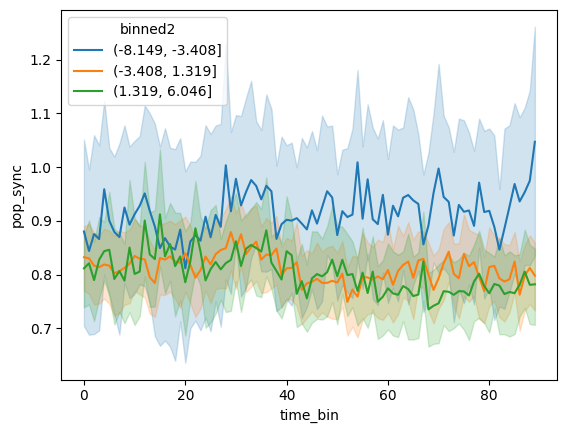

In [32]:
# plt.figure(figsize=(10, 5))
merged_df = summary_df.merge(lda[['session', 0, 1, 'binned1', 'binned2']], on='session', how='left')
sns.lineplot(data=merged_df, x='time_bin', y='pop_sync', hue='binned2', errorbar='ci')
plt.show()

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarni

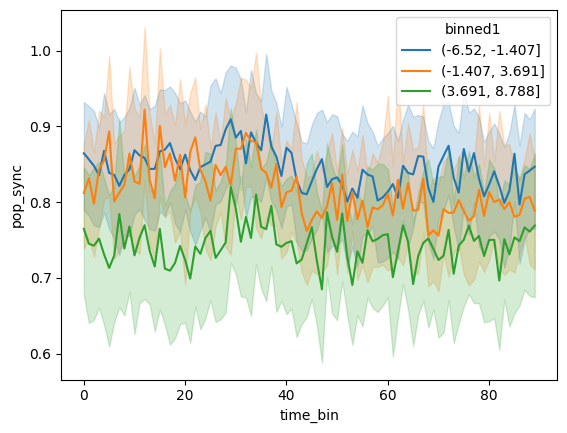

In [33]:
# plt.figure(figsize=(10, 5))
merged_df = summary_df.merge(lda[['session', 0, 1, 'binned1', 'binned2']], on='session', how='left')
sns.lineplot(data=merged_df, x='time_bin', y='pop_sync', hue='binned1', errorbar='ci')
plt.show()

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarni

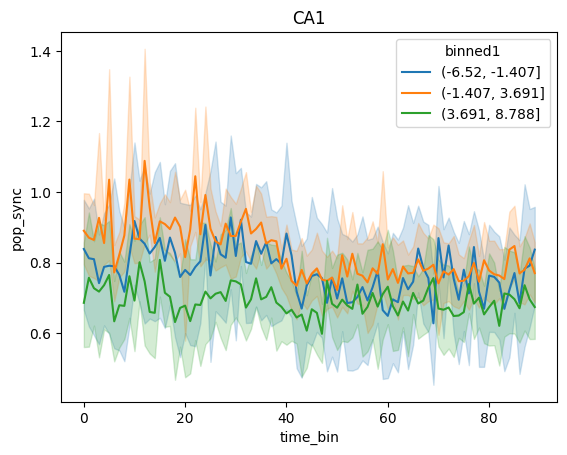

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarni

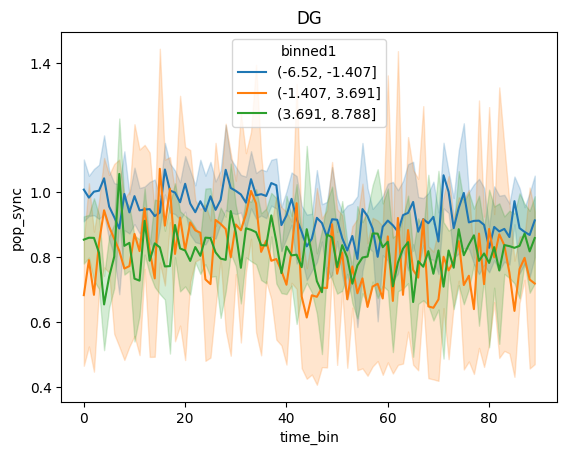

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarni

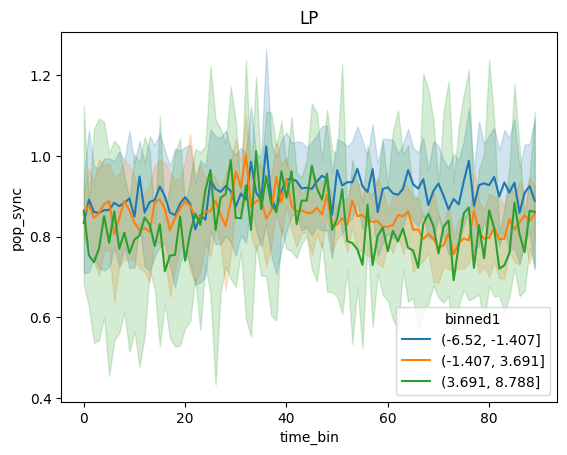

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarni

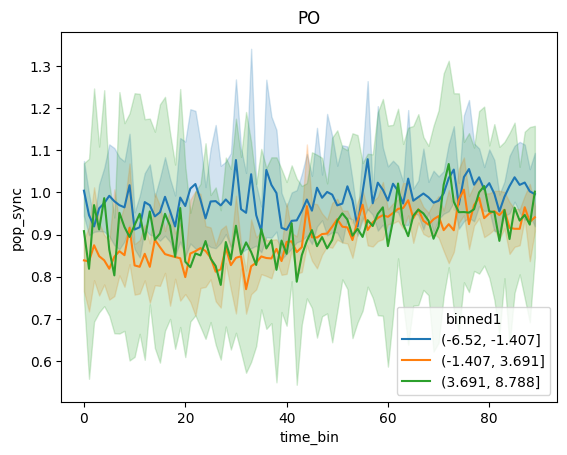

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarni

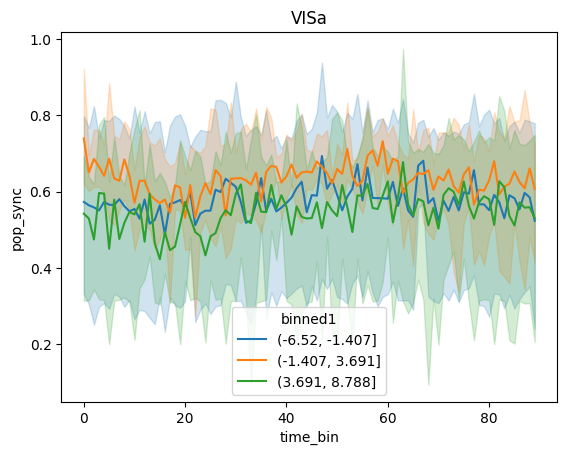

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarni

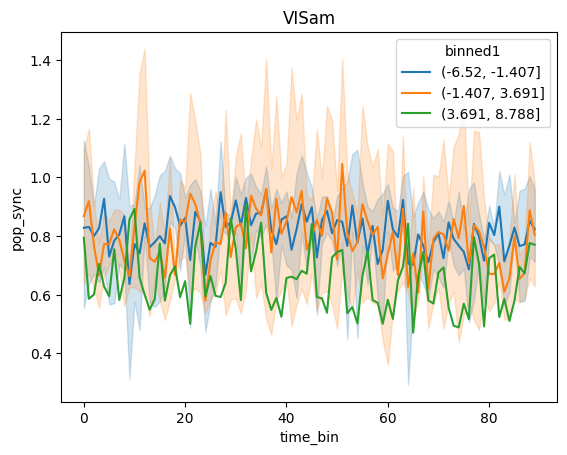

In [34]:
# plt.figure(figsize=(10, 5))
merged_df = summary_df.merge(lda[['session', 0, 1, 'binned1']], on='session', how='left')

for area in merged_df['area'].unique():
    area_data = merged_df[merged_df['area'] == area]
    sns.lineplot(data=area_data, x='time_bin', y='pop_sync', hue='binned1', errorbar='ci')
    plt.title(area)
    plt.show()

In [38]:
sns.swarmplot(y='pop_sync', x='binned1', data=merged_df.loc[merged_df['time_bin']>00])

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


KeyboardInterrupt: 

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 85.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 82.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 70.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Error in callback <function flush_figures at 0x7f844218c280> (for post_execute):


KeyboardInterrupt: 

In [ ]:
    # Use 'hue' for the continuous variable and 'palette' for the colormap
    sns.lineplot(
        data=merged_df, 
        x='time_bin', 
        y='pop_sync', 
        hue=0, 
        palette='viridis', 
        errorbar='sd',
        estimator='mean' # Ensures we average over sessions for each 'binned1' value
    )

ValueError: Could not interpret value `time_bin` for parameter `x`

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with 

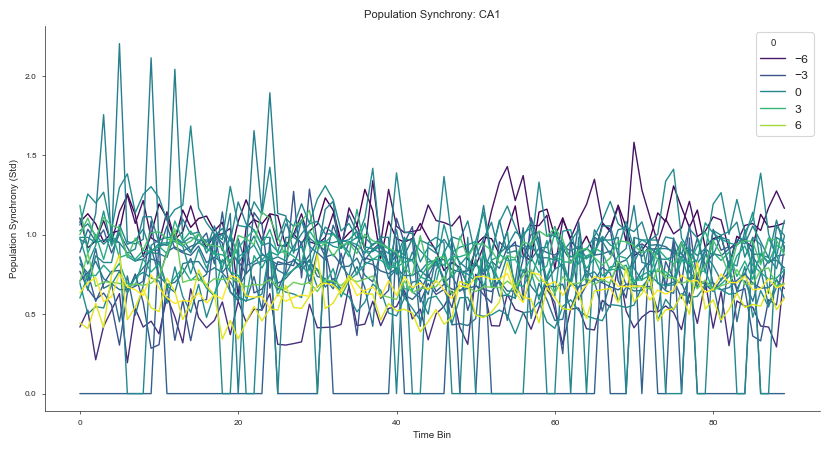

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with 

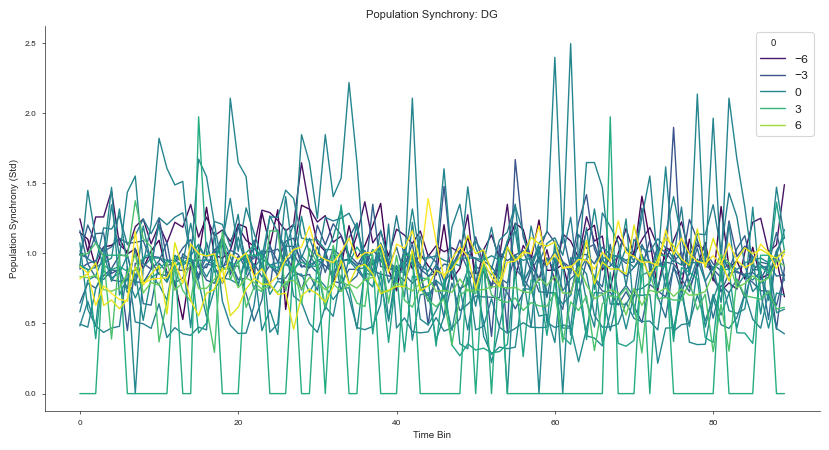

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with 

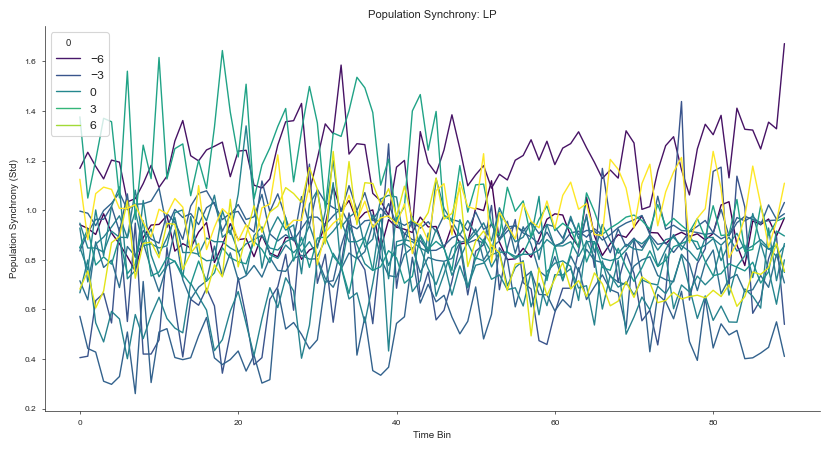

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with 

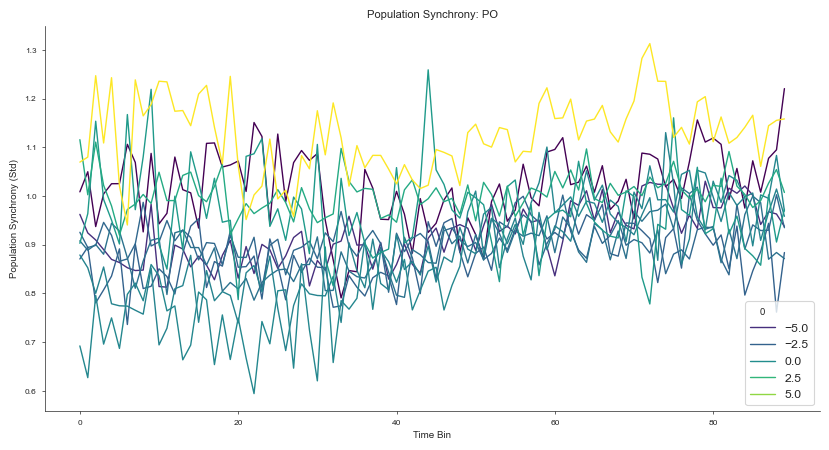

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with 

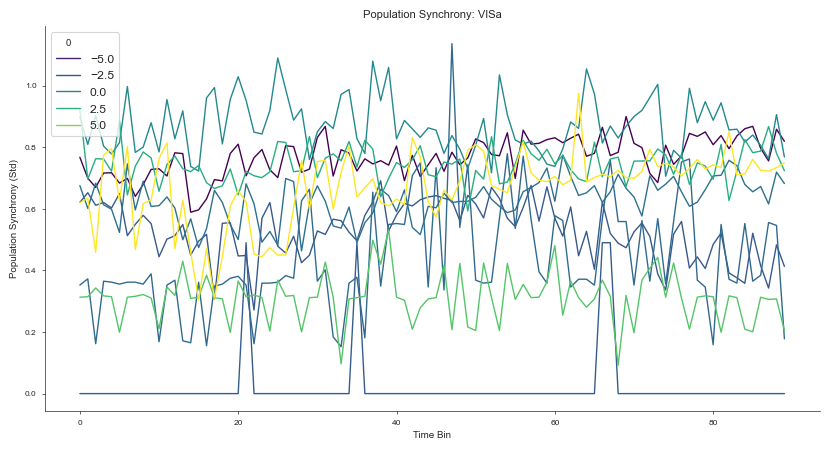

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with 

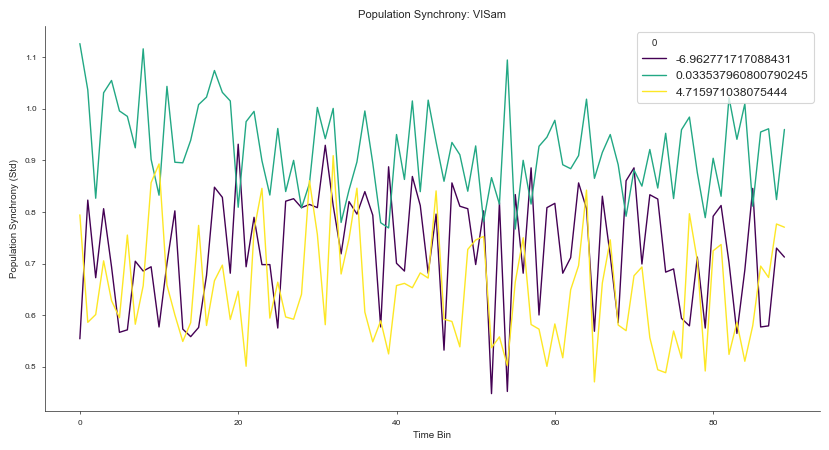

In [ ]:

# Ensure binned1 is numeric to get a continuous color bar
merged_df[0] = merged_df[0].astype(float)

# We use the 'palette' parameter to define a continuous colormap
# 'viridis', 'plasma', 'rocket', or 'magma' are excellent for continuous data
cmap = 'viridis' 

for area in merged_df['area'].unique():
    area_data = merged_df[merged_df['area'] == area]
    
    plt.figure(figsize=(10, 5))
    
    # Use 'hue' for the continuous variable and 'palette' for the colormap
    sns.lineplot(
        data=area_data, 
        x='time_bin', 
        y='pop_sync', 
        hue=0, 
        palette=cmap, 
        errorbar='sd',
        estimator='mean' # Ensures we average over sessions for each 'binned1' value
    )
    
    plt.title(f"Population Synchrony: {area}")
    plt.xlabel("Time Bin")
    plt.ylabel("Population Synchrony (Std)")
    
    # Optional: adjust the color bar
    # plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), label='Binned1 Intensity')
    plt.show()

In [ ]:
filepaths = [os.path.join(save_states_path, filename) for filename in os.listdir(save_states_path)][:1]
count_intersect = []
summary_df = pd.DataFrame()
for filepath in filepaths:
    try:
        with open(filepath, 'rb') as f:
            state_with_spikes = pickle.load(f).dropna(subset=['Bin', 'most_likely_states'])
            
        new_df = state_with_spikes.copy()
        session_name = state_with_spikes['session'].iloc[0]

        spike_columns = [col for col in state_with_spikes.columns if '_spike_count' in col]
        areas = [col.split('_neuron_')[0] for col in spike_columns]
        for area in areas:
            area_columns = [col for col in state_with_spikes.columns if area in col]
            new_df[f'{area}_spike_std'] = state_with_spikes[area_columns].std(axis=1)
            new_df[f'{area}_spike_mean'] = state_with_spikes[area_columns].mean(axis=1)
        area_columns = [f'{area}_spike_std' for area in np.unique(areas)]
        session_df = new_df.groupby(['broader_label'])[area_columns].mean().reset_index()

        session_df['session'] = session_name
        summary_df = pd.concat([summary_df, session_df], ignore_index=True)
        
    except Exception as e:
        print(f"Error processing {filepath}: {e}")


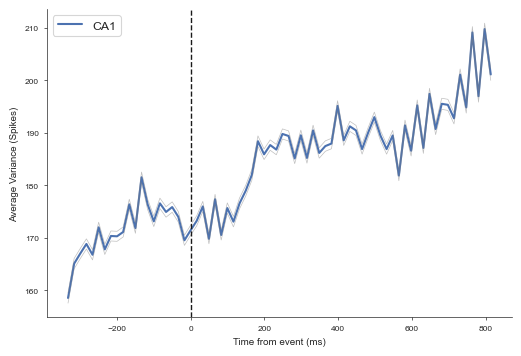

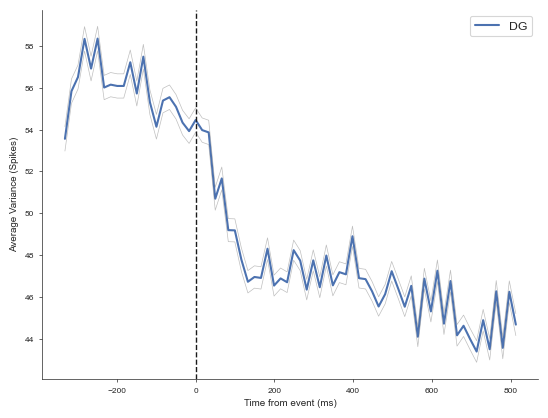

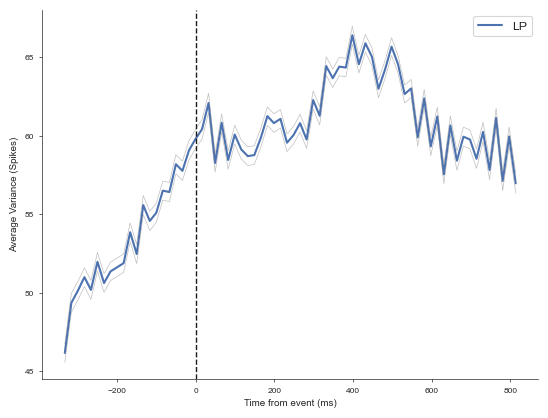

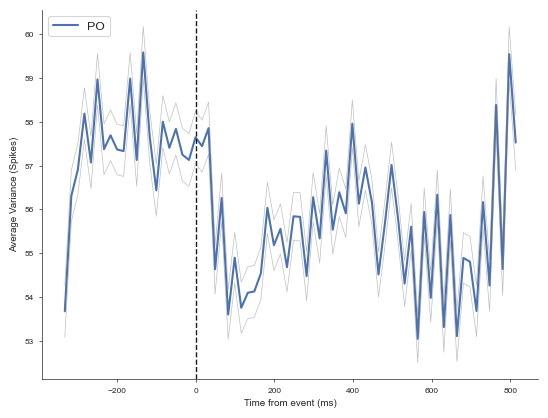

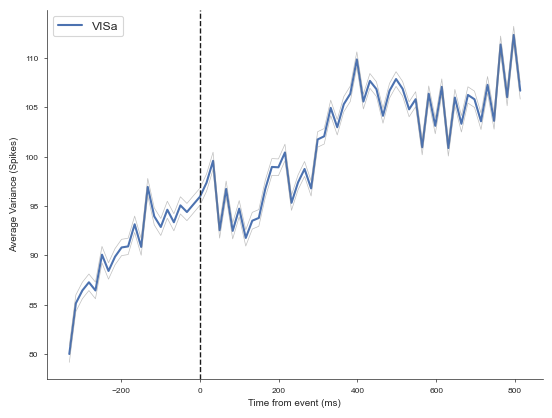

In [ ]:
event_bins = new_df[new_df['goCueTrigger_times'].notnull()].index
area_names = [c.replace('_spike_std', '') for c in new_df.columns if '_spike_std' in c]
plt.figure(figsize=(6, 4))
time_axis = np.arange(-20, 50) * 16.6 # Converting 60Hz bins to ms
for i, area in enumerate(area_names):
    psth_data = get_psth(new_df, area, event_bins) # shape: (n_trials, n_time_bins, n_areas)
    mean_psth = psth_data.mean(axis=0) # shape: (n_time_bins, n_areas)
    sem_psth = psth_data.std(axis=0) / np.sqrt(psth_data.shape[0]) # shape: (n_time_bins, n_areas)
    plt.plot(time_axis, mean_psth**2, label=area, linewidth=1.5)
    plt.plot(time_axis, mean_psth**2+sem_psth, linewidth=0.5, color='gray', alpha=0.5)
    plt.plot(time_axis, mean_psth**2-sem_psth, linewidth=0.5, color='gray', alpha=0.5)
    # plt.ylim([np.max(mean_psth**2-2*sem_psth), np.max(mean_psth**2+2*sem_psth)])
    plt.axvline(0, color='k', linestyle='--') # Event onset
    plt.xlabel('Time from event (ms)')
    plt.ylabel('Average Variance (Spikes)')
    plt.legend()
    plt.show()

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


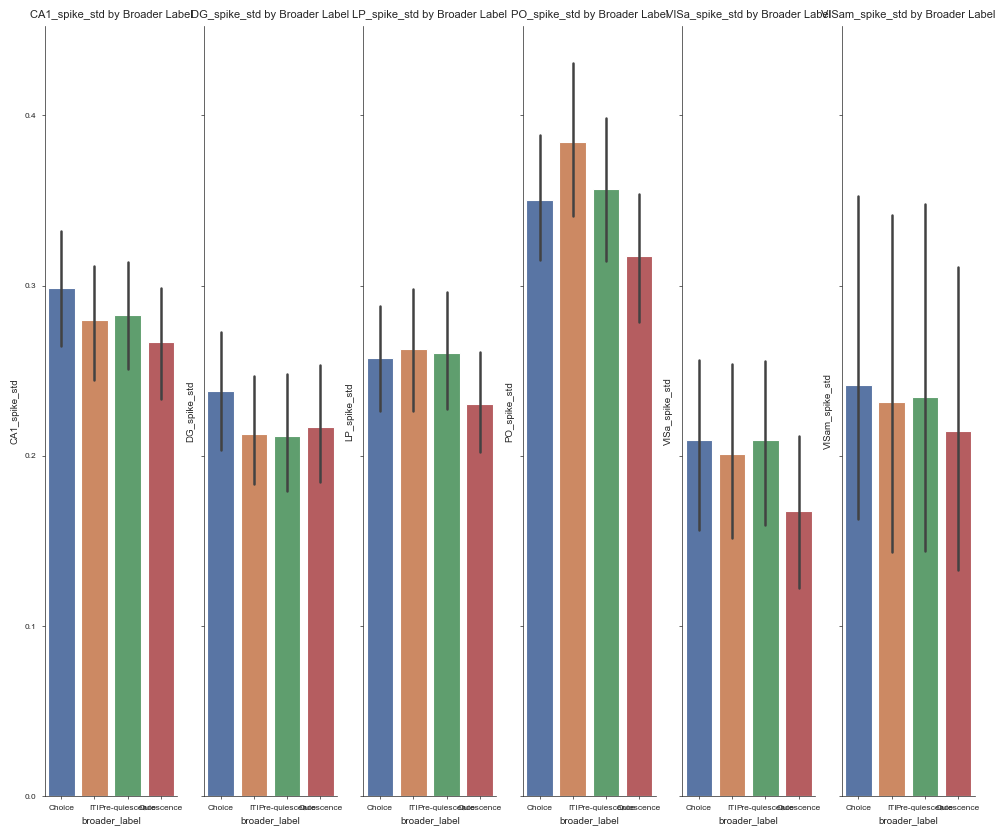

In [ ]:
areas = [ 'CA1_spike_std', 'DG_spike_std', 'LP_spike_std',
       'PO_spike_std', 'VISa_spike_std', 'VISam_spike_std']
# 2. Plotting loop
fig, ax = plt.subplots(nrows=1, ncols=len(areas), sharey=True, figsize=[12, 10])
for a, area in enumerate(areas):
    sns.barplot(data=summary_df, x='broader_label', y=area, ax=ax[a])
    ax[a].set_title(f'{area} by Broader Label')

## Linear mixed models

In [94]:
merged_df = summary_df.merge(lda[['mouse_name', 'session', 0, 1, 2, 3, 'binned1']], on='session', how='left')

In [300]:
import statsmodels.formula.api as smf
use_component = 0
var = 'ff_before_mean'
var = 'pop_sync'
# var = 'ff_after_mean'
var = 'ff_before_mean'
merged_df['quad_1'] = merged_df[0]**2
region_baseline = merged_df.groupby(['mouse_name', 'session', 'area',  0, 1, 2, 3])[var].mean().reset_index() #'brain_region', 
region_baseline = region_baseline.rename(columns={0:'lda_1'})
region_baseline = region_baseline.rename(columns={1:'lda_2'})
region_baseline = region_baseline.rename(columns={2:'lda_3'})
region_baseline = region_baseline.rename(columns={3:'lda_4'})

# 2. Define the model
groups = pd.Series(np.zeros(len(region_baseline)))  # dummy
# groups = region_baseline['mouse_name']
model = smf.mixedlm(
    "ff_before_mean ~ lda_1+lda_2+lda_3+lda_4", 
    region_baseline, 
    groups=groups, 
    re_formula="~1", 
    #vc_formula={"session": "0 + C(eid)"}
)
# 3. Fit the model
result = model.fit()

# 4. View the results
print(result.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ff_before_mean
No. Observations: 105     Method:             REML          
No. Groups:       1       Scale:              0.0494        
Min. group size:  105     Log-Likelihood:     -6.3715       
Max. group size:  105     Converged:          Yes           
Mean group size:  105.0                                     
-------------------------------------------------------------
              Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept      0.833     0.223   3.728  0.000   0.395   1.271
lda_1         -0.012     0.006  -1.831  0.067  -0.024   0.001
lda_2         -0.010     0.009  -1.155  0.248  -0.028   0.007
lda_3         -0.018     0.010  -1.728  0.084  -0.038   0.002
lda_4          0.007     0.016   0.463  0.643  -0.024   0.038
Group Var      0.049                                         



/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [304]:
# Step 1: Aggregate to the lowest level that varies (Area + Mouse)
region_baseline = merged_df.groupby(['mouse_name', 'session', 'area',  0, 1, 2, 3])[var].mean().reset_index() #'brain_region', 
grouped_data = region_baseline.rename(columns={0:'lda_1'})
grouped_data = grouped_data.rename(columns={1:'lda_2'})
grouped_data = grouped_data.rename(columns={2:'lda_3'})
grouped_data = grouped_data.rename(columns={3:'lda_4'})
# grouped_data = region_baseline.groupby(['mouse_name', 'area', 'lda_1']).mean().reset_index()

# Step 2: Use OLS with Cluster-Robust Standard Errors
# This accounts for the nesting without needing to solve complex random effects
model = smf.ols("ff_before_mean ~ lda_1 + lda_2 + lda_3 + lda_4 + C(area)", data=grouped_data)
results = model.fit(cov_type='cluster', cov_kwds={'groups': grouped_data['mouse_name']})

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:         ff_before_mean   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     7.625
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           1.45e-05
Time:                        11:48:27   Log-Likelihood:                 23.897
No. Observations:                 105   AIC:                            -27.79
Df Residuals:                      95   BIC:                            -1.254
Df Model:                           9                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.8234      0.047  

## Dimensionality reduction on single neuron PETH

In [139]:
# Initialize a list to hold the session-level PSTH data
all_session_mean = pd.DataFrame()
for filepath in filepaths:
    try:
        session_mean = pd.DataFrame()
        with open(filepath, 'rb') as f:
            state_with_spikes = pickle.load(f).dropna(subset=['Bin', 'most_likely_states'])
            
        new_df = state_with_spikes.reset_index(drop=True)
        session_name = state_with_spikes['session'].iloc[0]
        spike_columns = [col for col in new_df.columns if '_spike_count' in col]
        area_names = np.unique([col.split('_neuron_')[0] for col in spike_columns])
        events = np.array(new_df['goCueTrigger_times'].unique())

        for area in area_names:
            area_cols = [c for c in spike_columns if area in c]
            
            # 1. Get PSTH: (n_trials, n_time_bins, n_neurons_in_area)
            area_psths = [get_psth(new_df, col, events, pre=.5, post=1.5) for col in area_cols]
            area_psths = np.stack(area_psths, axis=-1) 

            area_baseline = [get_psth(new_df, col, events, pre=.2, post=0) for col in area_cols]
            area_baseline = np.stack(area_baseline, axis=-1)
            area_baseline = area_baseline[:np.shape(area_psths)[0], :, :] # Keep only same number of trials as area_psth
            area_baseline = area_baseline.mean(axis=1)

            baseline_subtracted_psths = (area_psths - area_baseline[:, np.newaxis, :]) / (area_baseline[:, np.newaxis, :]+0.01)

            # 2. Compute Statistics ACROSS TRIALS (axis=0)
            mean_across_trials = baseline_subtracted_psths.mean(axis=0)# (time, neurons)
            # mean_across_trials = np.stack(area_baseline, axis=-1).mean(axis=0)# (time, neurons)

            # var_across_trials = area_psths.var(axis=0)  # (time, neurons)

            # 7. Append to summary
            session_mean = pd.DataFrame(mean_across_trials.T)
            session_mean['session'] = session_name
            session_mean['area'] = area

            all_session_mean = pd.concat([all_session_mean, session_mean], ignore_index=True)

    except Exception as e:
        print(f"Error: {e}")


Error: invalid load key, '\x1b'.


In [152]:
lda = lda.rename(columns={0:'lda_1'})
lda = lda.rename(columns={1:'lda_2'})
# lda['binned1'] = np.random.permutation(lda['binned1'].values)
merged_data = all_session_mean.merge(lda[['session', 'lda_1', 'lda_2', 'binned1', 'binned2']], on='session', how='left')
merged_data.loc[merged_data['area']=='VISa', 'area'] = 'VISa/am'
merged_data.loc[merged_data['area']=='VISam', 'area'] = 'VISa/am'

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_10992/3772788508.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


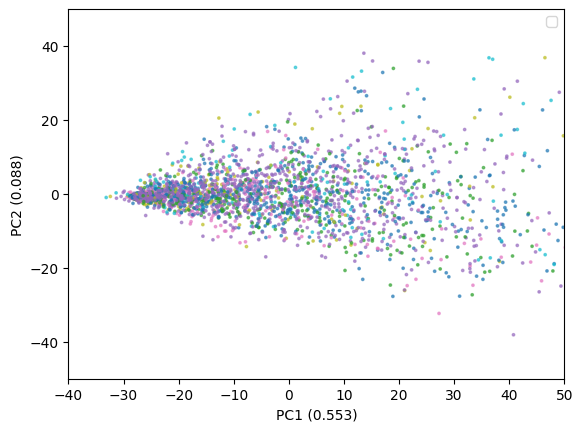

In [153]:
# 1. Select data and drop NaNs safely
subset = merged_data.copy()
subset_labels = subset['binned1']
# subset_labels = subset['area']
subset_lda1 = subset['lda_1']
subset = subset[np.arange(0, 90, 1)] 
subset = subset.dropna() # This drops rows with NaNs in the relevant columns

# 2. Check if we have data left
X = subset.values
# 4. Standardize (The StandardScaler already does the mean/std adjustment)
# scaler = StandardScaler()
# transformed = scaler.fit_transform(X)
transformed = X
pca = PCA()
pca_data = pca.fit_transform(transformed)
area_colors = subset_labels.astype('category').cat.codes
cmap = 'tab10'  # You can choose any colormap you like

# Plot PCA scatter (first two components)
plt.scatter(pca_data[:, 0], pca_data[:, 1], 
                            alpha=.6, s=3, c=area_colors, 
                            cmap=cmap)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')
plt.xlim([-40, 50])
plt.ylim([-50, 50])
# plt.ylim(-2, 2)
plt.legend()

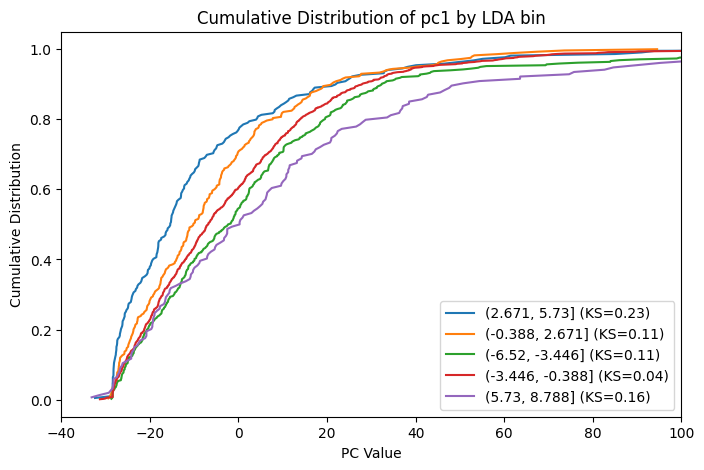

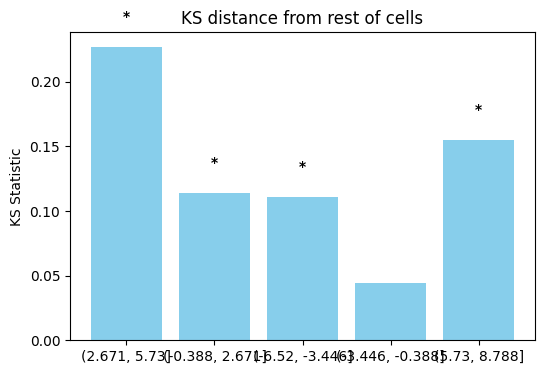

In [154]:
from scipy.stats import ks_2samp
use_pc = 'pc1'

# 1. Prepare Data
pca_df = pd.DataFrame(pca_data, columns=[f'pc{i+1}' for i in range(pca_data.shape[1])])
pca_df['area'] = subset_labels.values
pca_df = pca_df.dropna(subset=['area',use_pc])  # Ensure no NaNs in the relevant columns
pca_df['area'] = pca_df['area'].astype(str)
areas = pca_df['area'].unique()

plt.figure(figsize=(8, 5))
ks_results = {}

for area in areas:
    # Get PC1 values for current area and "rest of the brain"
    area_vals = pca_df[pca_df['area'] == area][use_pc].values
    rest_vals = pca_df[pca_df['area'] != area][use_pc].values
    
    # 2. Compute KS Statistic
    stat, p_val = ks_2samp(area_vals, rest_vals)
    ks_results[area] = {'stat': stat, 'p': p_val}
    
    # 3. Plot CDF
    # Sort values to create the CDF
    sorted_data = np.sort(area_vals)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    
    plt.plot(sorted_data, cdf, label=f"{area} (KS={stat:.2f})")
plt.xlim([-40, 100])
plt.xlabel('PC Value')
plt.ylabel('Cumulative Distribution')
plt.title('Cumulative Distribution of '+use_pc+' by LDA bin')
plt.legend()
plt.show()

# 4. Create the Inset Plot for KS Statistics
fig, ax = plt.subplots(figsize=(6, 4))
# Bar plot of KS statistics
areas_list = list(ks_results.keys())
stats = [ks_results[a]['stat'] for a in areas_list]
p_vals = [ks_results[a]['p'] for a in areas_list]

bars = ax.bar(areas_list, stats, color='skyblue')

# Add asterisks for p < 0.01
for i, p in enumerate(p_vals):
    if p < 0.01:
        ax.text(i, stats[i] + 0.02, '*', ha='center', fontweight='bold')
ax.set_ylabel('KS Statistic')
ax.set_title('KS distance from rest of cells')
plt.show()

In [246]:
subset = all_session_mean.copy()
subset['pca_1'] = pca_data[:, 0]
subset['pca_2'] = pca_data[:, 1]    

PearsonRResult(statistic=0.08782506480145774, pvalue=0.38007634826889336)


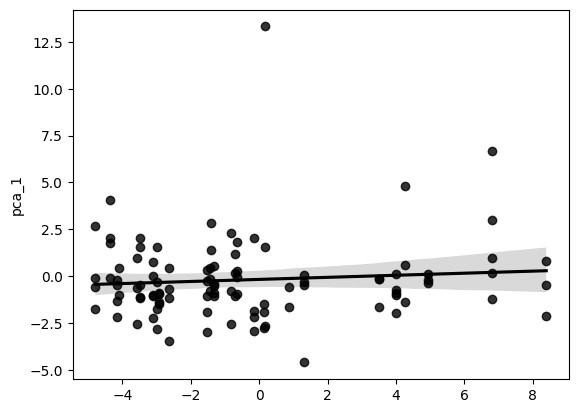

In [275]:
component = 'pca_1'

plot_df = subset.dropna().groupby(['session', 'area', 'lda_1'])[component].mean().reset_index()
sns.regplot(x=np.array(plot_df['lda_1']).astype(float), y=(plot_df[component]).astype(float), color='black', ci=95) 
res = stats.pearsonr(np.array(plot_df['lda_1']).astype(float), (plot_df[component]).astype(float))
print(res)

In [258]:
subset['pca_1'] = subset['pca_1'].astype(float)
subset['lda_1'] = subset['lda_1'].astype(float)
subset['lda_2'] = subset['lda_2'].astype(float)

In [259]:
import statsmodels.formula.api as smf
var = 'pca_1'

# 2. Define the model
groups = pd.Series(np.zeros(len(subset)))  # dummy
groups = pd.Series(pd.factorize(subset['session'])[0])
model = smf.mixedlm(
    "pca_1 ~ lda_1 + lda_2 + area", 
    subset, 
    groups=groups, 
    re_formula="~1", 
    #vc_formula={"session": "0 + C(eid)"}
)
# 3. Fit the model
result = model.fit()

# 4. View the results
print(result.summary())

IndexError: index 2025 is out of bounds for axis 0 with size 2025